# Stable Diffusion : plongée en profondeur

Stable Diffusion est un puissant modèle de texte à image. Il existe plusieurs sites web et outils pour rendre son utilisation aussi simple que possible. Il est également intégré à la bibliothèque de Diffusers d'Huggingface, ce qui permet de générer des images en toute simplicité :

In [ ]:
from diffusers import StableDiffusionPipeline
pipe = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4", revision="fp16", torch_dtype=torch.float16, use_auth_token=True).to("cuda")
image = pipe("An astronaught scuba diving").images[0]

Dans ce *notebook*, nous allons nous plonger dans le code qui se cache derrière ces interfaces faciles à utiliser, pour voir ce qui se passe sous le capot. Nous commencerons par recréer la fonctionnalité ci-dessus sous la forme d'un morceau de code effrayant, puis, un par un, nous inspecterons les différents composants et comprendrons ce qu'ils font. À la fin de ce *notebook*, cette même boucle d'échantillonnage devrait ressembler à quelque chose que vous pouvez peaufiner et modifier à votre guise.


## Configuration et importations

Vous devrez vous connecter à Hugging Face et accepter les termes de la licence pour ce modèle (voir la [carte de modèle](https://huggingface.co/CompVis/stable-diffusion-v1-4) pour plus de détails). Lorsque vous exécuterez ce *notebook* pour la première fois, vous devrez décommenter les deux cellules suivantes pour installer les prérequis et vous connecter au Hub avec un *token* d'accès.

In [ ]:
# !pip install -q --upgrade transformers diffusers ftfy

In [ ]:
from base64 import b64encode

import numpy
import torch
from diffusers import AutoencoderKL, LMSDiscreteScheduler, UNet2DConditionModel
from huggingface_hub import notebook_login

# Pour l'affichage vidéo
from IPython.display import HTML
from matplotlib import pyplot as plt
from pathlib import Path
from PIL import Image
from torch import autocast
from torchvision import transforms as tfms
from tqdm.auto import tqdm
from transformers import CLIPTextModel, CLIPTokenizer, logging

torch.manual_seed(1)
if not (Path.home()/'.huggingface'/'token').exists(): notebook_login()

# Suppression de certains avertissements inutiles lors du chargement de CLIPTextModel
logging.set_verbosity_error()

# Définir l'appareil
torch_device = "cuda" if torch.cuda.is_available() else "cpu"

## Chargement des modèles

Ce code (et celui de la section suivante) provient du [*notebook* illustratif d'Huggingface](https://colab.research.google.com/github/huggingface/notebooks/blob/main/diffusers/stable_diffusion.ipynb).

Il télécharge et configure les modèles et les composants que nous utiliserons. Exécutons-le pour l'instant et passons à la section suivante pour vérifier que tout fonctionne avant d'aller plus loin.

Si vous avez chargé un pipeline, vous pouvez aussi accéder à ces composants en utilisant `pipe.unet`, `pipe.vae` et ainsi de suite.

**Dans ce *notebook*, nous ne faisons pas d'économies de mémoire. Si vous vous retrouvez à court de RAM GPU, regardez le code du pipeline pour vous inspirer avec des choses comme le découpage de l'attention, le passage à la demi-précision (fp16), le maintien du VAE sur le CPU et d'autres modifications.**

In [ ]:
# Charger le modèle auto-encodeur qui sera utilisé pour décoder les latents dans l'espace de l'image
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae")

# Charger le tokenizer et l'encodeur
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14")

# Le modèle UNet pour générer les latents
unet = UNet2DConditionModel.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="unet")

# Le planificateur de bruit
scheduler = LMSDiscreteScheduler(beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", num_train_timesteps=1000)

# Nous allons au GPU !
vae = vae.to(torch_device)
text_encoder = text_encoder.to(torch_device)
unet = unet.to(torch_device);

## Une boucle de diffusion

Si tout ce que vous voulez, c'est créer une image avec du texte, vous pouvez ignorer ce notebook et utiliser l'un des outils existants (comme [DreamStudio](https://beta.dreamstudio.ai/generate)) ou utiliser le pipeline simplifié d'Hugging Face comme documenté [ici](https://huggingface.co/blog/stable_diffusion).

Ce que nous voulons faire ici, c'est approfondir un peu plus la façon dont cela fonctionne. Nous allons donc commencer par vérifier que le code de l'exemple s'exécute. Il ressemble beaucoup à ce que vous trouverez si vous inspectez la méthode [__call__()](https://github.com/huggingface/diffusers/blob/main/src/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion.py#L200) du pipeline de Stable Diffusion.

0it [00:00, ?it/s]

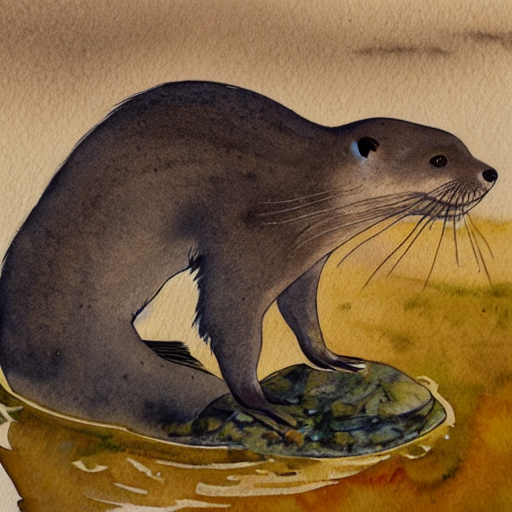

In [ ]:
# Quelques paramètres
prompt = ["A watercolor painting of an otter"]
height = 512                        # hauteur par défaut de Stable Diffusion
width = 512                         # largeur par défaut de Stable Diffusion
num_inference_steps = 30            # Nombre d'étapes de débruitage
guidance_scale = 7.5                # Échelle pour un guidage sans classifieur
generator = torch.manual_seed(32)   # Générateur de la graine pour créer le bruit latent initial
batch_size = 1

# Preparation du texte
text_input = tokenizer(prompt, padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt")
with torch.no_grad():
    text_embeddings = text_encoder(text_input.input_ids.to(torch_device))[0]
max_length = text_input.input_ids.shape[-1]
uncond_input = tokenizer(
    [""] * batch_size, padding="max_length", max_length=max_length, return_tensors="pt"
)
with torch.no_grad():
    uncond_embeddings = text_encoder(uncond_input.input_ids.to(torch_device))[0] 
text_embeddings = torch.cat([uncond_embeddings, text_embeddings])

# Preparation du planificateur
scheduler.set_timesteps(num_inference_steps)

# Preparation des latents
latents = torch.randn(
  (batch_size, unet.in_channels, height // 8, width // 8),
  generator=generator,
)
latents = latents.to(torch_device)
latents = latents * scheduler.init_noise_sigma # Mise à l'échelle (versions précédentes) latents = latents * self.scheduler.sigmas[0]

# Boucle
with autocast("cuda"):
    for i, t in tqdm(enumerate(scheduler.timesteps)):
        # étendre les latents si nous procédons à un guidage sans classifieur afin d'éviter de faire deux passages en avant        
		latent_model_input = torch.cat([latents] * 2)
        sigma = scheduler.sigmas[i]
        # mettre à l'échelle les latents (préconditionnement)
        # latent_model_input = latent_model_input / ((sigma**2 + 1) ** 0.5) # Diffusers 0.3 et moins
        latent_model_input = scheduler.scale_model_input(latent_model_input, t)

        # prédire le bruit résiduel
        with torch.no_grad():
            noise_pred = unet(latent_model_input, t, encoder_hidden_states=text_embeddings).sample

        # effectuer le guidage
        noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        # calculer l'échantillon bruité précédent x_t -> x_t-1
        # latents = scheduler.step(noise_pred, i, latents)["prev_sample"] # Diffusers 0.3 et moins
        latents = scheduler.step(noise_pred, t, latents).prev_sample

# mettre à l'échelle et décoder les latents de l'image à l'aide du vae
latents = 1 / 0.18215 * latents
with torch.no_grad():
    image = vae.decode(latents).sample

# Affichage
image = (image / 2 + 0.5).clamp(0, 1)
image = image.detach().cpu().permute(0, 2, 3, 1).numpy()
images = (image * 255).round().astype("uint8")
pil_images = [Image.fromarray(image) for image in images]
pil_images[0]

Cela fonctionne, mais cela fait beaucoup de code ! Examinons les composants un par un.

## L'auto-encodeur (AE)

L'AE peut encoder une image dans une sorte de représentation latente, et la décoder à nouveau en une image. Nous avons regroupé le code dans quelques fonctions pour que nous puissions voir à quoi cela ressemble en action :

In [ ]:
def pil_to_latent(input_im):
    # Une seule image -> un seul latent dans un batch (donc taille 1, 4, 64, 64)
    with torch.no_grad():
        latent = vae.encode(tfms.ToTensor()(input_im).unsqueeze(0).to(torch_device)*2-1) # Note scaling
    return 0.18215 * latent.latent_dist.sample()

def latents_to_pil(latents):
    # bain de latents -> liste d'images
    latents = (1 / 0.18215) * latents
    with torch.no_grad():
        image = vae.decode(latents).sample
    image = (image / 2 + 0.5).clamp(0, 1)
    image = image.detach().cpu().permute(0, 2, 3, 1).numpy()
    images = (image * 255).round().astype("uint8")
    pil_images = [Image.fromarray(image) for image in images]
    return pil_images

Nous utiliserons ici une image provenant du web, mais vous pouvez charger la vôtre en la téléchargeant et en modifiant le nom du fichier dans la cellule suivante.

In [ ]:
# Télécharger une image de démonstration
!curl --output macaw.jpg 'https://lafeber.com/pet-birds/wp-content/uploads/2018/06/Scarlet-Macaw-2.jpg'

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 62145  100 62145    0     0  10874      0  0:00:05  0:00:05 --:--:-- 15633


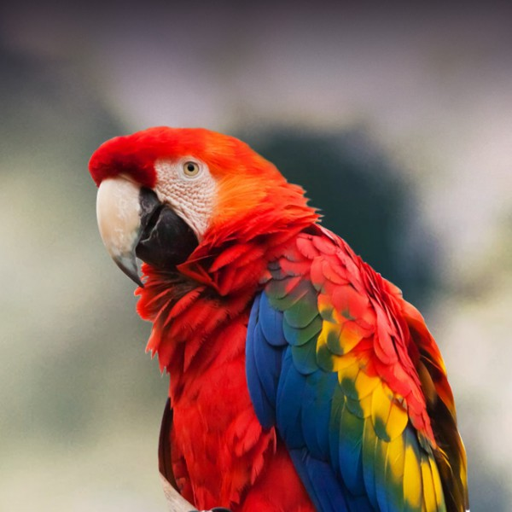

In [ ]:
# Charger l'image avec PIL
input_image = Image.open('macaw.jpg').resize((512, 512))
input_image

L'encodage dans l'espace latent de l'AE à l'aide de la fonction définie ci-dessus se présente comme suit :

In [ ]:
# Encoder dans l'espace latent
encoded = pil_to_latent(input_image)
encoded.shape

torch.Size([1, 4, 64, 64])

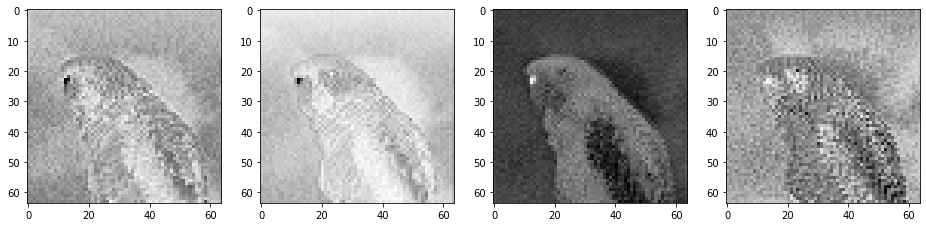

In [ ]:
# Visualisons les quatre canaux de cette représentation latente :
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for c in range(4):
    axs[c].imshow(encoded[0][c].cpu(), cmap='Greys')

Ce tenseur 4x64x64 capture de nombreuses informations sur l'image, suffisamment, espérons-le, pour que lorsque nous l'introduisons dans le décodeur, nous obtenions en retour quelque chose de très proche de notre image d'entrée :

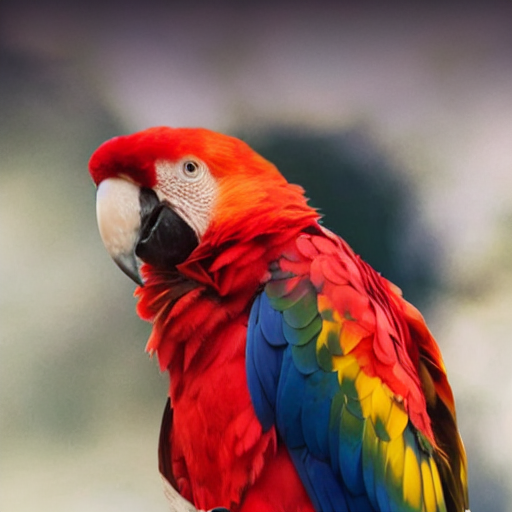

In [ ]:
# Décoder cette représentation latente en une image
decoded = latents_to_pil(encoded)[0]
decoded

Vous verrez de petites différences si vous plissez les yeux ! Concentrez-vous sur l'œil si vous ne voyez rien d'évident. C'est assez impressionnant : cette image latente de 4x64x64 semble contenir beaucoup plus d'informations qu'une image de 64px.

Cet auto-encodeur a été entraîné à réduire une image à une représentation plus petite, puis à recréer l'image à partir de cette version compressée.

Dans ce cas particulier, le facteur de compression est de 48, nous partons d'une image 3x512x512(cannaux x hauteur x largeur) et elle est compressée en un vecteur latent 4x64x64. Chaque volume de 3x8x8 pixels dans l'image d'entrée est compressé en seulement 4 nombres (4x1x1). Il est possible de trouver des AEs avec un taux de compression plus élevé (par exemple f16 comme certains modèles populaires de VQGAN) mais à un moment donné, ils commencent à introduire des artefacts que nous ne voulons pas.

Pourquoi utiliser un auto-encodeur ? Nous pouvons faire de la diffusion dans l'espace des pixels où le modèle reçoit toutes les données de l'image comme entrées et produit une prédiction de sortie de la même forme. Mais cela implique le traitement d'un grand nombre de données et rend la génération d'images à haute résolution très coûteuse sur le plan informatique. Certaines solutions consistent à effectuer la diffusion à basse résolution (64 px par exemple), puis à entraîner un modèle distinct pour augmenter l'échelle de manière répétée (comme avec D2/Imagen). La diffusion latente, quant à elle, effectue le processus de diffusion dans cet espace latent, en utilisant les représentations compressées de notre AE plutôt que des images brutes. Ces représentations sont riches en informations et peuvent être suffisamment petites pour être gérées par du matériel grand public. Une fois que nous avons généré une nouvelle image en tant que représentation latente, l'auto-encodeur peut prendre ces sorties latentes finales et les transformer en pixels réels.

# Le plannificateur
Nous devons maintenant parler de l'ajout de bruit.

Pendant l'entraînement, nous ajoutons du bruit à une image, puis nous demandons au modèle d'essayer de prédire le bruit. Si nous ajoutons toujours beaucoup de bruit, le modèle risque de ne pas avoir grand-chose à faire. Si nous n'en ajoutons qu'une infime quantité, le modèle ne pourra pas faire grand-chose avec les points de départ aléatoires que nous utilisons pour l'échantillonnage. Au cours de l'entraînement, la quantité de bruit varie donc en fonction d'une certaine distribution.

Pendant l'échantillonnage, nous voulons "débruiter" sur un certain nombre d'étapes. Le nombre d'étapes et la quantité de bruit que nous devons viser à chaque étape affecteront le résultat final.

Le planificateur est chargé de gérer tous ces détails. Par exemple : `scheduler = LMSDiscreteScheduler(beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", num_train_timesteps=1000)` met en place un scheduler qui correspond à celui utilisé pour entraîner ce modèle. Lorsque nous voulons échantillonner sur un plus petit nombre de pas, nous le faisons avec scheduler.set_timesteps :

In [ ]:
# Réglage du nombre de pas d'échantillonnage :
scheduler.set_timesteps(15)

Vous pouvez voir comment notre nouvel ensemble d'étapes correspond à celles utilisées dans l'entraînement :

In [ ]:
# Voyez ça en termes de 1000 étapes originales utilisées pour l'entraînement :
print(scheduler.timesteps)

tensor([999.0000, 927.6429, 856.2857, 784.9286, 713.5714, 642.2143, 570.8571,
        499.5000, 428.1429, 356.7857, 285.4286, 214.0714, 142.7143,  71.3571,
          0.0000], dtype=torch.float64)


Et quelle est la quantité de bruit présente à chaque endroit :

In [ ]:
# Examinez les niveaux de bruit équivalents :
print(scheduler.sigmas)

tensor([14.6146,  9.6826,  6.6780,  4.7746,  3.5221,  2.6666,  2.0606,  1.6156,
         1.2768,  1.0097,  0.7913,  0.6056,  0.4397,  0.2780,  0.0292,  0.0000])


Pendant l'échantillonnage, nous partons d'un niveau de bruit élevé (en fait, notre entrée sera du bruit pur) et nous "débruitons" progressivement jusqu'à obtenir une image, selon ce calendrier.

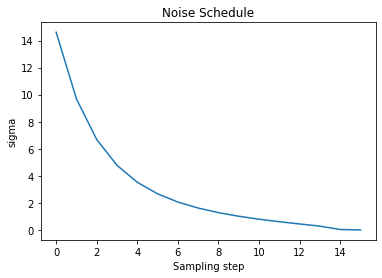

In [ ]:
# Affichage du planificateur de bruit :
plt.plot(scheduler.sigmas)
plt.title('Noise Schedule')
plt.xlabel('Sampling step')
plt.ylabel('sigma')
plt.show()

Ce "sigma" est la quantité de bruit ajoutée à la représentation latente. Voyons ce que cela donne en ajoutant un peu de bruit à notre image codée, puis en décodant cette version bruitée :

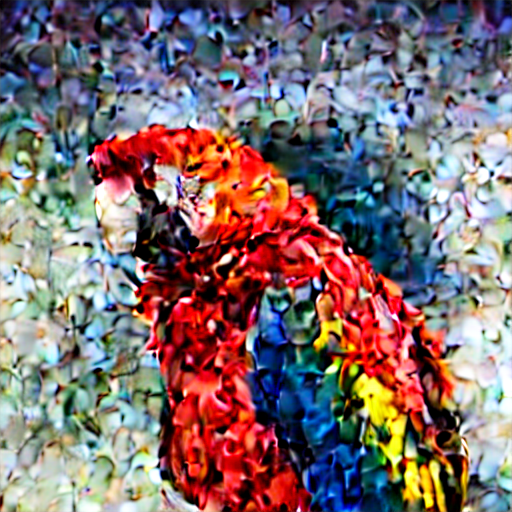

In [ ]:
noise = torch.randn_like(encoded) # Bruit aléatoire
sampling_step = 10 # Equivalent à une étape 10 sur 15 dans la grille ci-dessus
# encoded_and_noised = scheduler.add_noise(encoded, noise, timestep) # Diffusers 0.3 et en dessous
encoded_and_noised = scheduler.add_noise(encoded, noise, timesteps=torch.tensor([scheduler.timesteps[sampling_step]]))
latents_to_pil(encoded_and_noised.float())[0] # Affichage

À quoi cela ressemble-t-il à différents pas de temps ? Faites l'expérience et voyez par vous-même !

Si vous décommentez la cellule ci-dessous, vous verrez que dans ce cas, la fonction `scheduler.add_noise` ne fait qu'ajouter du bruit à l'échelle sigma : `noisy_samples = original_samples + noise * sigmas`

In [ ]:
# ??scheduler.add_noise

D'autres modèles de diffusion peuvent être entraînés avec différentes approches de bruits et d'ordonnancement, dont certaines maintiennent la variance relativement constante entre les niveaux de bruit ("préservation de la variance") avec différentes astuces de mise à l'échelle et de mélange au lieu d'avoir des latents bruités avec une variance de plus en plus élevée au fur et à mesure que l'on ajoute du bruit ("explosion de la variance").

Si nous voulons partir d'un bruit aléatoire au lieu d'une image bruitée, nous devons la mettre à l'échelle de la plus grande valeur sigma utilisée pendant l'entraînement, soit ~14 dans ce cas. Et avant que ces latents bruités ne soient introduits dans le modèle, ils sont à nouveau mis à l'échelle dans l'étape dite de pré-conditionnement : `latent_model_input = latent_model_input / ((sigma**2 + 1) ** 0.5)` (maintenant géré par `latent_model_input = scheduler.scale_model_input(latent_model_input, t)`).

Encore une fois, cette mise à l'échelle/pré-conditionnement diffère entre les articles et les implémentations, alors gardez un œil sur ce point si vous travaillez avec un type différent de modèle de diffusion.

## Boucle à partir de la version bruitée de l'entrée (aka image2image)

Voyons ce qui se passe lorsque nous utilisons notre image comme point de départ, en ajoutant un peu de bruit et en effectuant les dernières étapes de débruitage dans la boucle avec un nouveau prompt.

Nous allons utiliser une boucle similaire à celle de la première démonstration, mais nous allons sauter les premières étapes `start_step`.

Pour bruiter notre image, nous utiliserons un code comme celui montré ci-dessus, en utilisant le planificateur pour la bruiter à un niveau équivalent à l'étape 10 (`start_step`).

0it [00:00, ?it/s]

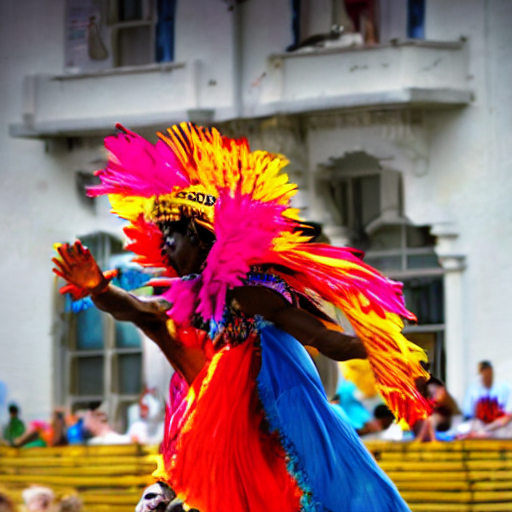

In [ ]:
# Paramètres (les mêmes que précédemment, à l'exception du nouveau prompt)
prompt = ["A colorful dancer, nat geo photo"]
height = 512                        # hauteur par défaut de Stable Diffusion
width = 512                         # largeur par défaut de Stable Diffusion
num_inference_steps = 30            # Nombre d'étapes de débruitage
guidance_scale = 7.5                # Échelle pour un guidage sans classifieur
generator = torch.manual_seed(32)   # Générateur de la graine pour créer le bruit latent initial
batch_size = 1

# Preparation du texte (comme précédemment)
text_input = tokenizer(prompt, padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt")
with torch.no_grad():
    text_embeddings = text_encoder(text_input.input_ids.to(torch_device))[0]
max_length = text_input.input_ids.shape[-1]
uncond_input = tokenizer(
    [""] * batch_size, padding="max_length", max_length=max_length, return_tensors="pt"
)
with torch.no_grad():
    uncond_embeddings = text_encoder(uncond_input.input_ids.to(torch_device))[0] 
text_embeddings = torch.cat([uncond_embeddings, text_embeddings])

# Preparation du planificateur (définition du nombre d'étapes de l'inférence)
scheduler.set_timesteps(num_inference_steps)

# Preparation des latents (bruitage approprié pour start_step)
start_step = 10
start_sigma = scheduler.sigmas[start_step]
noise = torch.randn_like(encoded)
latents = scheduler.add_noise(encoded, noise, timesteps=torch.tensor([scheduler.timesteps[start_step]]))
latents = latents.to(torch_device).float()

# Boucle
for i, t in tqdm(enumerate(scheduler.timesteps)):
    if i >= start_step: # << C'est la seule modification que nous apportons à la boucle.
        
        # étendre les latents si nous procédons à un guidage sans classifieur afin d'éviter de faire deux passages en avant  
        latent_model_input = torch.cat([latents] * 2)
        sigma = scheduler.sigmas[i]
        latent_model_input = scheduler.scale_model_input(latent_model_input, t)

        # prédire le bruit résiduel
        with torch.no_grad():
            noise_pred = unet(latent_model_input, t, encoder_hidden_states=text_embeddings)["sample"]

        # effectuer le guidage
        noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        # calculer l'échantillon bruité précédent x_t -> x_t-1
        latents = scheduler.step(noise_pred, t, latents).prev_sample

latents_to_pil(latents)[0]

Vous pouvez voir que certaines couleurs et structures de l'image sont conservées, mais nous avons maintenant une nouvelle image ! Plus vous ajoutez de bruit et plus vous effectuez d'étapes, plus l'image s'éloigne de l'image d'entrée.

C'est ainsi que fonctionne le célèbre pipeline img2img. Encore une fois, si c'est votre objectif final, il existe des outils qui facilitent la tâche !

Mais vous pouvez voir que sous le capot, c'est la même chose que la boucle de génération, en sautant les premières étapes et en partant d'une image bruitée plutôt que d'une image purement bruitée.

Essayez de changer le nombre d'étapes sautées et de voir comment cela affecte la quantité de changement de l'image par rapport à l'entrée.

## Exploration du pipeline texte -> enchâssement

Nous utilisons un modèle d'encodage de texte pour transformer notre texte en un ensemble d'enchâssements qui sont transmis au modèle de diffusion en tant que conditionnement. Suivons un morceau de texte tout au long de ce processus et voyons comment il fonctionne.

In [ ]:
# Notre prompt textuel
prompt = 'A picture of a puppy'

Nous commençons par la tokenisation :

In [ ]:
# Transformer le texte en une séquence de tokens :
text_input = tokenizer(prompt, padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt")
text_input['input_ids'][0] # Voir les tokens

tensor([49406,   320,  1674,   539,   320,  6829, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407])

In [ ]:
# Voir les tokens individuels
for t in text_input['input_ids'][0][:8]: # Nous nous contenterons d'examiner les 7 premiers pour vous éviter un mur d'<|endoftext|>'
    print(t, tokenizer.decoder.get(int(t)))

tensor(49406) <|startoftext|>
tensor(320) a</w>
tensor(1674) picture</w>
tensor(539) of</w>
tensor(320) a</w>
tensor(6829) puppy</w>
tensor(49407) <|endoftext|>
tensor(49407) <|endoftext|>


Nous pouvons passer directement aux enchâssements finaux (de sortie) de la manière suivante :

In [ ]:
# Récupérer les enchâssements de sortie
output_embeddings = text_encoder(text_input.input_ids.to(torch_device))[0]
print('Shape:', output_embeddings.shape)
output_embeddings

Shape: torch.Size([1, 77, 768])


tensor([[[-0.3884,  0.0229, -0.0522,  ..., -0.4899, -0.3066,  0.0675],
         [ 0.0290, -1.3258,  0.3085,  ..., -0.5257,  0.9768,  0.6652],
         [ 0.6942,  0.3538,  1.0991,  ..., -1.5716, -1.2643, -0.0121],
         ...,
         [-0.0221, -0.0053, -0.0089,  ..., -0.7303, -1.3830, -0.3011],
         [-0.0062, -0.0246,  0.0065,  ..., -0.7326, -1.3745, -0.2953],
         [-0.0536,  0.0269,  0.0444,  ..., -0.7159, -1.3634, -0.3075]]],
       device='cuda:0', grad_fn=<NativeLayerNormBackward0>)

Nous passons nos *tokens* à travers text_encoder et nous obtenons comme par magie des nombres que nous pouvons introduire dans le modèle.

Comment ces chiffres sont-ils générés ? Les tokens sont transformés en un ensemble d'enchâssements d'entrée, qui sont ensuite introduits dans le transformer pour obtenir les enchâssements de sortie finaux.

Pour obtenir ces enchâssements d'entrée, il y a en fait deux étapes comme le révèle l'inspection de `text_encoder.text_model.embeddings` :

In [ ]:
text_encoder.text_model.embeddings

CLIPTextEmbeddings(
  (token_embedding): Embedding(49408, 768)
  (position_embedding): Embedding(77, 768)
)

## Enchâssement de tokens

Le *token* est envoyé à la fonction `token_embedding` pour le transformer en vecteur. Le nom de la fonction `get_input_embeddings` est trompeur puisque ces enchâssements de *tokens* doivent être combinés avec les enchâssements de positions avant d'être utilisés comme entrées dans le modèle ! Quoi qu'il en soit, examinons d'abord la partie relative à l'enchâssements des *tokens*.

Nous pouvons regarder la couche d'enchâssement :

In [ ]:
# Accéder à la couche enchâssement
token_emb_layer = text_encoder.text_model.embeddings.token_embedding
token_emb_layer # Taille du vocabulaire 49408, emb_dim 768

Embedding(49408, 768)

Et enchâsser un *token* comme suit :

In [ ]:
# Enchâsser un *token*, dans ce cas, celui du "chiot"
embedding = token_emb_layer(torch.tensor(6829, device=torch_device))
embedding.shape # représentation en 768-dim

torch.Size([768])

Cet unique *tokens* a été associé avec un vecteur à 768 dimensions.

Nous pouvons faire la même chose avec tous les *tokens* du prompt pour obtenir tous les enchâssements de *tokens* :

In [ ]:
token_embeddings = token_emb_layer(text_input.input_ids.to(torch_device))
print(token_embeddings.shape) # taille du batch 1, 77 *tokens*, 768 valeurs pour chaque
token_embeddings

torch.Size([1, 77, 768])


tensor([[[ 0.0011,  0.0032,  0.0003,  ..., -0.0018,  0.0003,  0.0019],
         [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
         [ 0.0235, -0.0118,  0.0110,  ...,  0.0049,  0.0078,  0.0160],
         ...,
         [ 0.0012,  0.0077, -0.0011,  ..., -0.0015,  0.0009,  0.0052],
         [ 0.0012,  0.0077, -0.0011,  ..., -0.0015,  0.0009,  0.0052],
         [ 0.0012,  0.0077, -0.0011,  ..., -0.0015,  0.0009,  0.0052]]],
       device='cuda:0', grad_fn=<EmbeddingBackward0>)

## Enchâssements positionnels

Les enchâssements positionnels indiquent au modèle à quel endroit d'une séquence se trouve un *token*. Tout comme l'enchâssement de * tokens*, il s'agit d'un ensemble de paramètres (qui peuvent éventuellement être appris). Mais maintenant, au lieu de traiter ~50k *tokens* nous avons juste besoin d'un pour chaque position (77 au total) :

In [ ]:
pos_emb_layer = text_encoder.text_model.embeddings.position_embedding
pos_emb_layer

Embedding(77, 768)

Nous pouvons obtenir l'enchâssement positionnel pour chaque position :

In [ ]:
position_ids = text_encoder.text_model.embeddings.position_ids[:, :77]
position_embeddings = pos_emb_layer(position_ids)
print(position_embeddings.shape)
position_embeddings

torch.Size([1, 77, 768])


tensor([[[ 0.0016,  0.0020,  0.0002,  ..., -0.0013,  0.0008,  0.0015],
         [ 0.0042,  0.0029,  0.0002,  ...,  0.0010,  0.0015, -0.0012],
         [ 0.0018,  0.0007, -0.0012,  ..., -0.0029, -0.0009,  0.0026],
         ...,
         [ 0.0216,  0.0055, -0.0101,  ..., -0.0065, -0.0029,  0.0037],
         [ 0.0188,  0.0073, -0.0077,  ..., -0.0025, -0.0009,  0.0057],
         [ 0.0330,  0.0281,  0.0289,  ...,  0.0160,  0.0102, -0.0310]]],
       device='cuda:0', grad_fn=<EmbeddingBackward0>)

## Combiner les enchâssements de *tokens* et de positions

Il est temps de combiner les deux. Comment faire ? Il suffit de les additionner ! D'autres approches sont possibles, mais pour ce modèle, c'est ainsi que nous procédons.

En les combinant de cette manière, nous obtenons les enchâssements d'entrée finaux, prêts à être introduits dans le *transformer* :

In [ ]:
# En les combinant, nous obtenons les enchâssements d'entrée finaux
input_embeddings = token_embeddings + position_embeddings
print(input_embeddings.shape)
input_embeddings

torch.Size([1, 77, 768])


tensor([[[ 2.6770e-03,  5.2133e-03,  4.9323e-04,  ..., -3.1321e-03,
           1.0659e-03,  3.4316e-03],
         [ 5.5371e-03,  1.7510e-03, -1.2381e-02,  ..., -1.1410e-02,
           1.3508e-02,  6.8378e-03],
         [ 2.5356e-02, -1.1019e-02,  9.7663e-03,  ...,  1.9460e-03,
           6.8375e-03,  1.8573e-02],
         ...,
         [ 2.2781e-02,  1.3262e-02, -1.1241e-02,  ..., -8.0054e-03,
          -2.0560e-03,  8.9366e-03],
         [ 2.0026e-02,  1.5015e-02, -8.7638e-03,  ..., -4.0313e-03,
           1.8487e-05,  1.0885e-02],
         [ 3.4206e-02,  3.5826e-02,  2.7768e-02,  ...,  1.4465e-02,
           1.1110e-02, -2.5745e-02]]], device='cuda:0', grad_fn=<AddBackward0>)

Nous pouvons vérifier que ces résultats sont les mêmes que ceux obtenus avec `text_encoder.text_model.embeddings` :

In [ ]:
# La procédure suivante combine toutes les étapes ci-dessus (mais ne nous permet pas de les modifier !)
text_encoder.text_model.embeddings(text_input.input_ids.to(torch_device))

tensor([[[ 2.6770e-03,  5.2133e-03,  4.9323e-04,  ..., -3.1321e-03,
           1.0659e-03,  3.4316e-03],
         [ 5.5371e-03,  1.7510e-03, -1.2381e-02,  ..., -1.1410e-02,
           1.3508e-02,  6.8378e-03],
         [ 2.5356e-02, -1.1019e-02,  9.7663e-03,  ...,  1.9460e-03,
           6.8375e-03,  1.8573e-02],
         ...,
         [ 2.2781e-02,  1.3262e-02, -1.1241e-02,  ..., -8.0054e-03,
          -2.0560e-03,  8.9366e-03],
         [ 2.0026e-02,  1.5015e-02, -8.7638e-03,  ..., -4.0313e-03,
           1.8487e-05,  1.0885e-02],
         [ 3.4206e-02,  3.5826e-02,  2.7768e-02,  ...,  1.4465e-02,
           1.1110e-02, -2.5745e-02]]], device='cuda:0', grad_fn=<AddBackward0>)

## Passage dans le *transformer*

![transformer diagram](https://github.com/johnowhitaker/tglcourse/raw/main/images/text_encoder_noborder.png)

Nous voulons modifier les enchâssements d'entrée (en particulier les enchâssements de tokens) avant de les envoyer dans le reste du modèle, mais nous devons d'abord nous assurer que nous savons comment le faire. Nous avons lu le code de la méthode `forward` du text_encoder, et nous nous sommes basés sur ce code pour la méthode `forward` du text_model que le text_encoder englobe. Pour l'inspecter vous-même, tapez `??text_encoder.text_model.forward` et vous obtiendrez les informations sur la fonction et le code source, une astuce de débogage utile !

Quoi qu'il en soit, nous pouvons copier les bits dont nous avons besoin pour obtenir ce que l'on appelle le "dernier état caché" et ainsi générer nos enchâssements finaux :

In [ ]:
def get_output_embeds(input_embeddings):
    # Le modèle de texte de CLIP utilise le masquage causal, c'est pourquoi nous le préparons ici :
    bsz, seq_len = input_embeddings.shape[:2]
    causal_attention_mask = text_encoder.text_model._build_causal_attention_mask(bsz, seq_len, dtype=input_embeddings.dtype)

	# Obtenir les enchâssements de sortie implique d'appeler le modèle en passant output_hidden_states=True 
    # afin qu'il ne renvoie pas uniquement les prédictions finales regroupées :
    encoder_outputs = text_encoder.text_model.encoder(
        inputs_embeds=input_embeddings,
        attention_mask=None, # Nous n'utilisons pas de masque d'attention, cela peut donc être None.
        causal_attention_mask=causal_attention_mask.to(torch_device),
        output_attentions=None,
        output_hidden_states=True, # Nous voulons le résultat des enchâssements et non le résultat final.
        return_dict=None,
    )

    # Seul l'état caché de sortie nous intéresse
    output = encoder_outputs[0]

    # Il existe une normalisation de couche finale par laquelle nous devons passer
    output = text_encoder.text_model.final_layer_norm(output)

    # Et maintenant, elles sont prêtes !
    return output

out_embs_test = get_output_embeds(input_embeddings) # Alimenter le modèle à l'aide de notre nouvelle fonction
print(out_embs_test.shape) # Vérifier la forme de la sortie
out_embs_test # Inspecter la sortie

torch.Size([1, 77, 768])


tensor([[[-0.3884,  0.0229, -0.0522,  ..., -0.4899, -0.3066,  0.0675],
         [ 0.0290, -1.3258,  0.3085,  ..., -0.5257,  0.9768,  0.6652],
         [ 0.6942,  0.3538,  1.0991,  ..., -1.5716, -1.2643, -0.0121],
         ...,
         [-0.0221, -0.0053, -0.0089,  ..., -0.7303, -1.3830, -0.3011],
         [-0.0062, -0.0246,  0.0065,  ..., -0.7326, -1.3745, -0.2953],
         [-0.0536,  0.0269,  0.0444,  ..., -0.7159, -1.3634, -0.3075]]],
       device='cuda:0', grad_fn=<NativeLayerNormBackward0>)

Notez que cela correspond aux `output_embeddings` que nous avons vu au début. Nous avons trouvé comment diviser cette étape ("obtenir les enchâssements") en plusieurs sous-étapes prêtes à être modifiées.

Maintenant que nous avons mis en place ce processus, nous pouvons remplacer l'encodage d'entrée d'un *token* par un nouvel encodage de notre choix, ce qui dans notre cas d'utilisation final, sera quelque chose que nous apprendrons. Pour démontrer le concept, remplaçons l'encodage d'entrée de "*puppy*" dans le prompt avec lequel nous avons joué avec l'enchâssement du *token* 2368, obtenons un nouvel ensemble d'enchâssement de sortie basés sur celui-ci et utilisons-les pour générer une image afin de voir ce que nous obtenons :

In [ ]:
prompt = 'A picture of a puppy'

# Tokeniser
text_input = tokenizer(prompt, padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt")
input_ids = text_input.input_ids.to(torch_device)

# Obtenir les enchâssements des tokens
token_embeddings = token_emb_layer(input_ids)

# Le nouvel enchâssement. Dans ce cas, il s'agit simplement de l'enchâssement d'entrée du token 2368
replacement_token_embedding = text_encoder.get_input_embeddings()(torch.tensor(2368, device=torch_device))

# Insérer ceci dans les enchâssements de token
token_embeddings[0, torch.where(input_ids[0]==6829)] = replacement_token_embedding.to(torch_device)

# Combiner avec le'enchâssement positionnel
input_embeddings = token_embeddings + position_embeddings

# Passage dans le transformer pour obtenir les enchâssements finaux
modified_output_embeddings = get_output_embeds(input_embeddings)

print(modified_output_embeddings.shape)
modified_output_embeddings

torch.Size([1, 77, 768])


tensor([[[-0.3884,  0.0229, -0.0522,  ..., -0.4899, -0.3066,  0.0675],
         [ 0.0290, -1.3258,  0.3085,  ..., -0.5257,  0.9768,  0.6652],
         [ 0.6942,  0.3538,  1.0991,  ..., -1.5716, -1.2643, -0.0121],
         ...,
         [-0.6034, -0.5322,  0.0629,  ..., -0.3964,  0.0877, -0.9558],
         [-0.5936, -0.5407,  0.0731,  ..., -0.3876,  0.0906, -0.9436],
         [-0.6393, -0.4703,  0.1103,  ..., -0.3904,  0.1351, -0.9726]]],
       device='cuda:0', grad_fn=<NativeLayerNormBackward0>)

Les premiers sont identiques, les derniers ne le sont pas. Tout ce qui se trouve à la position du *token* que nous remplaçons et après sera affecté.

Si tout s'est bien passé, nous devrions voir autre chose qu'un chiot lorsque nous les utiliserons pour générer une image. Et bien sûr, c'est le cas !

In [ ]:
# Génération d'une image avec ces enchâssements modifiés

def generate_with_embs(text_embeddings):
	height = 512                        # hauteur par défaut de Stable Diffusion
	width = 512                         # largeur par défaut de Stable Diffusion
	num_inference_steps = 30            # Nombre d'étapes de débruitage
	guidance_scale = 7.5                # Échelle pour un guidage sans classifieur
	generator = torch.manual_seed(32)   # Générateur de la graine pour créer le bruit latent initial
    batch_size = 1

    max_length = text_input.input_ids.shape[-1]
    uncond_input = tokenizer(
      [""] * batch_size, padding="max_length", max_length=max_length, return_tensors="pt"
    )
    with torch.no_grad():
        uncond_embeddings = text_encoder(uncond_input.input_ids.to(torch_device))[0] 
    text_embeddings = torch.cat([uncond_embeddings, text_embeddings])

    # Preparation du planificateur
    scheduler.set_timesteps(num_inference_steps)

    # Preparation des latents
    latents = torch.randn(
    (batch_size, unet.in_channels, height // 8, width // 8),
    generator=generator,
    )
    latents = latents.to(torch_device)
    latents = latents * scheduler.init_noise_sigma

    # Boucle
    for i, t in tqdm(enumerate(scheduler.timesteps)):
        # étendre les latents si nous procédons à un guidage sans classifieur afin d'éviter de faire deux passages en avant
        latent_model_input = torch.cat([latents] * 2)
        sigma = scheduler.sigmas[i]
        latent_model_input = scheduler.scale_model_input(latent_model_input, t)

        # prédire le bruit résiduel
        with torch.no_grad():
            noise_pred = unet(latent_model_input, t, encoder_hidden_states=text_embeddings)["sample"]

        # réaliser un guidage
        noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        # calculer l'échantillon bruité précédent x_t -> x_t-1
        latents = scheduler.step(noise_pred, t, latents).prev_sample

    return latents_to_pil(latents)[0]

0it [00:00, ?it/s]

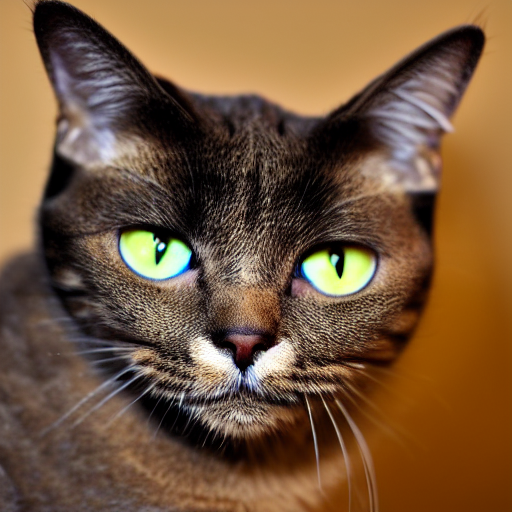

In [ ]:
generate_with_embs(modified_output_embeddings)

Surprise ! Vous savez maintenant ce que signifie le *token* 2368.

Que pouvons-nous en faire ? Pourquoi nous sommes-nous donné tout ce mal ? Eh bien, nous verrons bientôt un cas d'utilisation plus convaincant, mais en résumé, une fois que nous pouvons accéder aux enchâssements de *tokens* et les modifier, nous pouvons faire des choses comme les remplacer par autre chose. Dans l'exemple que nous venons de faire, il s'agissait simplement d'un autre enchâssement de *tokens* du vocabulaire du modèle, ce qui équivaut à une simple modification du prompt. Mais nous pouvons également mélanger les *tokens*. Par exemple, voici un mi-chiot / mi-mouflette :

In [ ]:
# Au cas où vous vous demanderiez comment obtenir le *token* d'un mot, ou l'enchâssement d'un *token* :
prompt = 'skunk'
print('tokenizer(prompt):', tokenizer(prompt))
print('token_emb_layer([token_id]) shape:', token_emb_layer(torch.tensor([8797], device=torch_device)).shape)

tokenizer(prompt): {'input_ids': [49406, 42194, 49407], 'attention_mask': [1, 1, 1]}
token_emb_layer([token_id]) shape: torch.Size([1, 768])


0it [00:00, ?it/s]

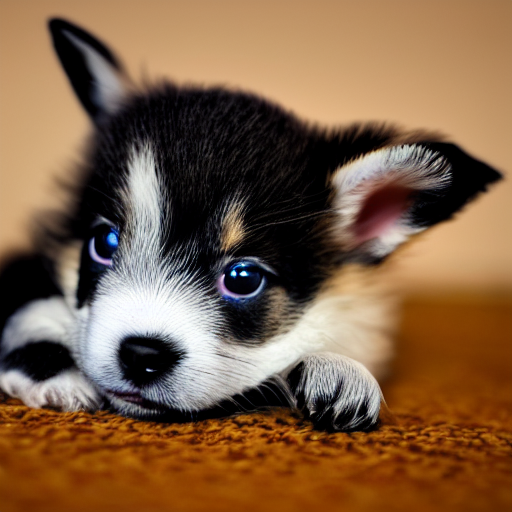

In [ ]:
prompt = 'A picture of a puppy'

# Tokeniser
text_input = tokenizer(prompt, padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt")
input_ids = text_input.input_ids.to(torch_device)

# Obtenir les enchâssements des tokens
token_embeddings = token_emb_layer(input_ids)

# Le nouvel enchâssement. Il s'agit maintenant d'un mélange d'enchâssement des tokens "puppy" et "skunk"
puppy_token_embedding = token_emb_layer(torch.tensor(6829, device=torch_device))
skunk_token_embedding = token_emb_layer(torch.tensor(42194, device=torch_device))
replacement_token_embedding = 0.5*puppy_token_embedding + 0.5*skunk_token_embedding

# Insérer ceci dans les enchâssements de token
token_embeddings[0, torch.where(input_ids[0]==6829)] = replacement_token_embedding.to(torch_device)

# Combiner avec le'enchâssement positionnel
input_embeddings = token_embeddings + position_embeddings

# Passage dans le transformer pour obtenir les enchâssements finaux
modified_output_embeddings = get_output_embeds(input_embeddings)

# Générer une image
generate_with_embs(modified_output_embeddings)

## Inversion textuelle

Nous pouvons donc insérer un enchâssement de *token* modifié et l'utiliser pour générer une image. Nous avons utilisé l'enchâssement de *token* pour "chat" dans l'exemple ci-dessus, mais que se passerait-il si nous pouvions "apprendre" un nouvel enchâssement de *token* pour un concept spécifique ? C'est l'idée qui sous-tend l'"Inversion textuelle", dans laquelle quelques exemples d'images sont utilisés pour créer un nouvel enchâssement de *token* :

![Overview image from the blog post](https://textual-inversion.github.io/static/images/training/training.JPG)
_Diagramme tiré de l'[article de blog](https://textual-inversion.github.io/) sur l'inversion textuelle. Notez qu'il ne montre pas l'étape des enchâssements positionnels pour des raisons de simplicité._  
 
Nous ne verrons pas comment cet entraînement fonctionne, mais nous pouvons essayer de charger l'un de ces nouveaux "concepts" à partir de la [bibliothèque de concepts SD créée par la communauté](https://huggingface.co/sd-concepts-library) et voir comment il s'intègre dans notre exemple ci-dessus. Nous utiliserons [https://huggingface.co/sd-concepts-library/birb-style](https://huggingface.co/sd-concepts-library/birb-style) puisque c'est le premier que nous avons créé. Téléchargez le fichier learned_embeds.bin à partir de là et téléchargez-le à l'endroit où se trouve ce *notebook* avant d'exécuter la cellule suivante :


In [ ]:
birb_embed = torch.load('learned_embeds.bin')
birb_embed.keys(), birb_embed['<birb-style>'].shape

(dict_keys(['<birb-style>']), torch.Size([768]))

Nous obtenons un dictionnaire avec une clé et l'enchâssement de *token* correspondant. Comme dans l'exemple précédent, remplaçons l'enchâssement  de "puppy" par celui-ci et voyons ce qui se passe :

0it [00:00, ?it/s]

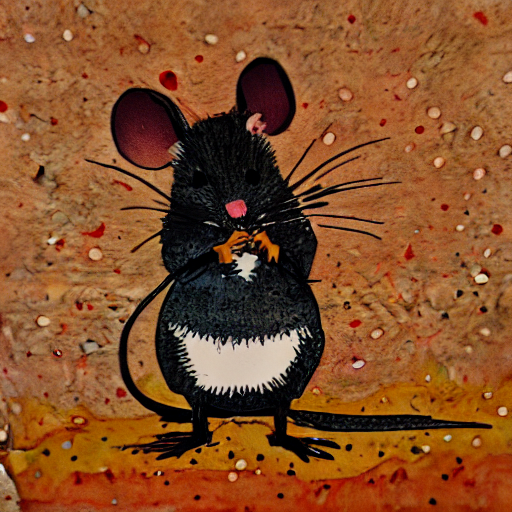

In [ ]:
prompt = 'A mouse in the style of puppy'

# Tokeniser
text_input = tokenizer(prompt, padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt")
input_ids = text_input.input_ids.to(torch_device)

# Obtenir les enchâssements des tokens
token_embeddings = token_emb_layer(input_ids)

# Le nouvel enchâssement, notre mot d'ordre spécial
replacement_token_embedding = birb_embed['<birb-style>'].to(torch_device)

# Insérer ceci dans les enchâssements de token
token_embeddings[0, torch.where(input_ids[0]==6829)] = replacement_token_embedding.to(torch_device)

# Combiner avec le'enchâssement positionnel
input_embeddings = token_embeddings + position_embeddings

# Passage dans le transformer pour obtenir les enchâssements finaux
modified_output_embeddings = get_output_embeds(input_embeddings)

# Générer une image
generate_with_embs(modified_output_embeddings)

Le *token* a été remplacé par une expression qui représente un style particulier de peinture, mais il pourrait tout aussi bien représenter un objet ou une classe d'objets spécifique.

Encore une fois, il existe un [beau *notebook* d'inférence](https://colab.research.google.com/github/huggingface/notebooks/blob/main/diffusers/stable_conceptualizer_inference.ipynb) d'Hugging Face pour faciliter l'utilisation des différents concepts, qui gère correctement l'utilisation des noms dans les prompts ("*A <cat-toy> in the style of <birb-style>*") sans se préoccuper de toutes ces choses manuelles.

## Mélanger les enchâssements

Outre le simple remplacement de l'enchâssement des tokens d'un seul mot, il existe d'autres astuces que nous pouvons essayer. Par exemple, que se passe-t-il si nous créons une "chimère" en calculant la moyenne des enchâssements de deux prompts différents ?

0it [00:00, ?it/s]

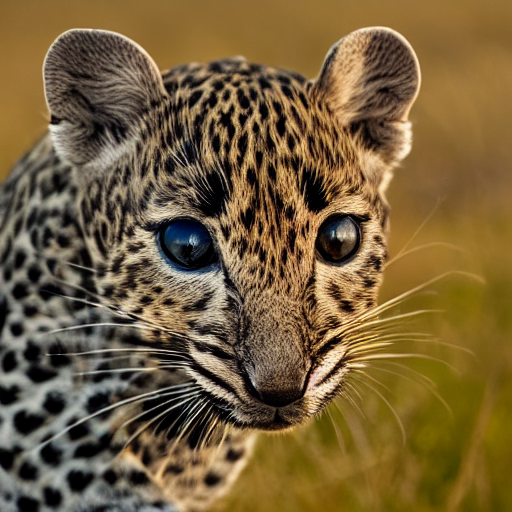

In [ ]:
# Enchâsser deux prompts
text_input1 = tokenizer(["A mouse"], padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt")
text_input2 = tokenizer(["A leopard"], padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt")
with torch.no_grad():
    text_embeddings1 = text_encoder(text_input1.input_ids.to(torch_device))[0]
    text_embeddings2 = text_encoder(text_input2.input_ids.to(torch_device))[0]

# Les mixer ensemble
mix_factor = 0.35
mixed_embeddings = (text_embeddings1*mix_factor + \
                   text_embeddings2*(1-mix_factor))

# Generer
generate_with_embs(mixed_embeddings)

## L'UNet et le CFG (*Classifier Free Guidance*)

Il est maintenant temps d'examiner le modèle de diffusion proprement dit. Il s'agit généralement d'un UNet qui prend en compte les latents bruyants (x) et prédit le bruit. Nous utilisons un modèle conditionnel qui prend également en compte le pas de temps (t) et notre enchâssement de texte (aka encoder_hidden_states) comme conditionnement. L'introduction de tous ces éléments dans le modèle se présente comme suit : `noise_pred = unet(latents, t, encoder_hidden_states=text_embeddings)["sample"]`

Nous pouvons l'essayer et voir à quoi ressemble le résultat :

In [ ]:
# Preparation du planificateur
scheduler.set_timesteps(num_inference_steps)

# Quel est notre pas de temps ?
t = scheduler.timesteps[0]
sigma = scheduler.sigmas[0]

# Un latent bruyant
latents = torch.randn(
  (batch_size, unet.in_channels, height // 8, width // 8),
  generator=generator,
)
latents = latents.to(torch_device)
latents = latents * scheduler.init_noise_sigma

# L'enchâssement du texte
text_input = tokenizer(['A macaw'], padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt")
with torch.no_grad():
    text_embeddings = text_encoder(text_input.input_ids.to(torch_device))[0]

# Passage dans l'UNet pour prédire le bruit résiduel
with torch.no_grad():
    noise_pred = unet(latents, t, encoder_hidden_states=text_embeddings)["sample"]

latents.shape, noise_pred.shape # Nous obtenons des prédictions de la même forme que l'entrée.

(torch.Size([1, 4, 64, 64]), torch.Size([1, 4, 64, 64]))

Étant donné un ensemble de latents bruyants, le modèle prédit la composante de bruit. Nous pouvons retirer ce bruit des latents bruyants pour voir à quoi ressemble l'image de sortie (`latents_x0 = latents - sigma * noise_pred`). Et nous pouvons ajouter la plus grande partie du bruit à cette sortie prédite pour obtenir l'entrée (légèrement moins bruitée, espérons-le) pour l'étape de diffusion suivante. Pour visualiser cela, générons une autre image, en sauvegardant à la fois la sortie prédite (x0) et l'étape suivante (xt-1) après chaque étape :

In [ ]:
prompt = 'Oil painting of an otter in a top hat'
height = 512                      
width = 512                        
num_inference_steps = 50
guidance_scale = 8    
generator = torch.manual_seed(32)
batch_size = 1

# Créer un dossier pour stocker les résultats
!rm -rf steps/
!mkdir -p steps/

# Preparation du texte 
text_input = tokenizer([prompt], padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt")
with torch.no_grad():
    text_embeddings = text_encoder(text_input.input_ids.to(torch_device))[0]
max_length = text_input.input_ids.shape[-1]
uncond_input = tokenizer(
    [""] * batch_size, padding="max_length", max_length=max_length, return_tensors="pt"
)
with torch.no_grad():
    uncond_embeddings = text_encoder(uncond_input.input_ids.to(torch_device))[0] 
text_embeddings = torch.cat([uncond_embeddings, text_embeddings])

# Preparation du planificateur
scheduler.set_timesteps(num_inference_steps)

# Preparation des latents
latents = torch.randn(
  (batch_size, unet.in_channels, height // 8, width // 8),
  generator=generator,
)
latents = latents.to(torch_device)
latents = latents * scheduler.init_noise_sigma

# Boucle
for i, t in tqdm(enumerate(scheduler.timesteps)):
    # étendre les latents si nous procédons à un guidage sans classifieur afin d'éviter de faire deux passages en avant
    latent_model_input = torch.cat([latents] * 2)
    sigma = scheduler.sigmas[i]
    latent_model_input = scheduler.scale_model_input(latent_model_input, t)

    # prédire le bruit résiduel
    with torch.no_grad():
        noise_pred = unet(latent_model_input, t, encoder_hidden_states=text_embeddings)["sample"]

    # effectuer le guidage
    noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
    noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)
    
    # Obtenir la valeur prédite x0 :
    # latents_x0 = latents - sigma * noise_pred # Calculer nous-mêmes
    latents_x0 = scheduler.step(noise_pred, t, latents).pred_original_sample # Utilisation du planificateur (Diffuseurs 0.4 et plus)

    # calculer l'échantillon bruité précédent x_t -> x_t-1
    latents = scheduler.step(noise_pred, t, latents).prev_sample

    # Vers des images PIL
    im_t0 = latents_to_pil(latents_x0)[0]
    im_next = latents_to_pil(latents)[0]

    # Combinez les deux images et enregistrez-les pour une visualisation ultérieure
    im = Image.new('RGB', (1024, 512))
    im.paste(im_next, (0, 0))
    im.paste(im_t0, (512, 0))
    im.save(f'steps/{i:04}.jpeg')

0it [00:00, ?it/s]

In [ ]:
# Réaliser et diffuser la vidéo sur l'état d'avancement (modifier la largeur à 1024 pour une pleine résolution)
!ffmpeg -v 1 -y -f image2 -framerate 12 -i steps/%04d.jpeg -c:v libx264 -preset slow -qp 18 -pix_fmt yuv420p out.mp4
mp4 = open('out.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=600 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

La version de droite montre la "sortie finale" prédite (x0) à chaque étape, et c'est ce qui est généralement utilisé pour les vidéos de progression, etc. La version de gauche représente l'étape suivante. Nous trouvons intéressant de comparer les deux, en regardant les vidéos de progression, on pourrait penser que des changements radicaux se produisent, en particulier aux premiers stades, mais comme les changements apportés à chaque étape sont relativement faibles, le processus réel est beaucoup plus progressif.

### CFG (*Classifier Free Guidance*)

Par défaut, le modèle ne fait pas souvent ce que nous lui demandons. Si nous voulons qu'il suive mieux le prompt, nous utilisons un hack appelé CFG. Il y a une bonne explication dans cette vidéo [video](https://www.youtube.com/watch?v=344w5h24-h8) d'AI Coffee Break with Letitia.

Dans le code, cela revient à faire :

`noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)`

Cela fonctionne étonnamment bien :) Essayez de changer le guidance_scale dans le code ci-dessus et voyez comment cela affecte les résultats. Jusqu'où pouvez-vous aller avant que les résultats n'empirent ?


## Échantillonnage

Il y a encore de la complexité cachée dans `latents = scheduler.step(noise_pred, i, latents)["prev_sample"]`. Comment l'échantillonneur passe-t-il exactement des latents bruyants actuels à une version légèrement moins bruyante ? Pourquoi ne pas utiliser le modèle en une seule étape ? Existe-t-il d'autres façons de voir les choses ?

Le modèle tente de prédire le bruit dans une image. Pour des valeurs de bruit faibles, nous supposons qu'il fait un assez bon travail. Pour des niveaux de bruit plus élevés, la tâche est ardue ! Ainsi, au lieu de produire une image parfaite, les résultats ont tendance à ressembler à un désordre flou. Voir le début de la vidéo citée à l'instant pour une illustration ! Les échantillonneurs utilisent donc les prédictions du modèle pour s'en rapprocher légèrement (en éliminant une partie du bruit), puis obtiennent une autre prédiction basée sur cette entrée marginalement moins mauvaise, en espérant que cela améliorera le résultat de manière itérative.

Les différents échantillonneurs procèdent de différentes manières. Vous pouvez essayer d'inspecter le code de l'échantillonneur LMS par défaut avec :

In [ ]:
# ??scheduler.step

## Guidage

Ok, dernière astuce ! Comment pouvons-nous ajouter un contrôle supplémentaire à ce processus de génération ?

À chaque étape, nous allons utiliser notre modèle comme précédemment pour prédire la composante bruit de $x$. Ensuite, nous allons l'utiliser pour produire une image de sortie prédite, et appliquer une fonction de perte à cette image.

Cette fonction peut être n'importe quoi, mais nous allons faire une démonstration avec un exemple très simple. Si nous voulons des images avec beaucoup de bleu, nous pouvons créer une fonction de perte qui donne une perte élevée si les pixels ont une faible composante bleue :

In [ ]:
def blue_loss(images):
    # Quelle est la distance entre les valeurs du canal bleu et 0,9 ?
    error = torch.abs(images[:,2] - 0.9).mean() # [:,2] -> toutes les images dans le batch, seulement le canal bleu
    return error

Lors de chaque étape de mise à jour, nous trouvons le gradient de la perte par rapport aux latents bruyants actuels et nous les modifions dans la direction qui réduit cette perte tout en effectuant l'étape de mise à jour normale :

0it [00:00, ?it/s]

0 loss: 182.02133178710938
10 loss: 43.55351257324219
20 loss: 15.30621337890625
30 loss: 9.746519088745117
40 loss: 8.846868515014648


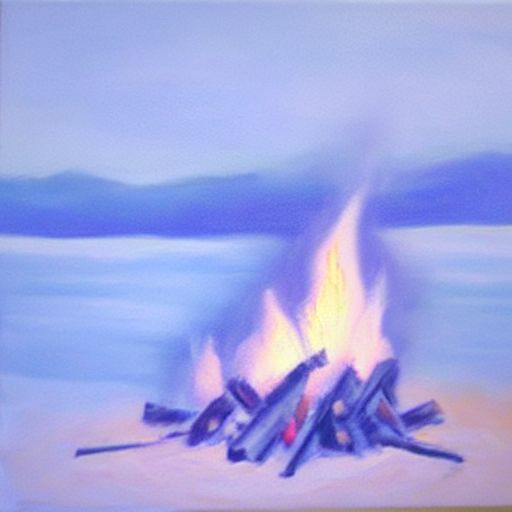

In [ ]:
prompt = 'A campfire (oil on canvas)' #@param
height = 512                        # hauteur par défaut de Stable Diffusion
width = 512                         # largeur par défaut de Stable Diffusion
num_inference_steps = 50  #@param           # Nombre d'étapes de débruitage
guidance_scale = 8 #@param               # Échelle pour un guidage sans classifieur
generator = torch.manual_seed(32)   # Générateur de graines pour créer le bruit latent initial
batch_size = 1
blue_loss_scale = 200 #@param

# Preparation du texte 
text_input = tokenizer([prompt], padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt")
with torch.no_grad():
    text_embeddings = text_encoder(text_input.input_ids.to(torch_device))[0]

# Et l'entrée non conditionnelle comme précédemment :
max_length = text_input.input_ids.shape[-1]
uncond_input = tokenizer(
    [""] * batch_size, padding="max_length", max_length=max_length, return_tensors="pt"
)
with torch.no_grad():
    uncond_embeddings = text_encoder(uncond_input.input_ids.to(torch_device))[0] 
text_embeddings = torch.cat([uncond_embeddings, text_embeddings])

# Preparation du planificateur
scheduler.set_timesteps(num_inference_steps)

# Preparation des latents
latents = torch.randn(
  (batch_size, unet.in_channels, height // 8, width // 8),
  generator=generator,
)
latents = latents.to(torch_device)
latents = latents * scheduler.init_noise_sigma

# Boucle
for i, t in tqdm(enumerate(scheduler.timesteps)):
    # étendre les latents si nous procédons à un guidage sans classifieur afin d'éviter de faire deux passages en avant
    latent_model_input = torch.cat([latents] * 2)
    sigma = scheduler.sigmas[i]
    latent_model_input = scheduler.scale_model_input(latent_model_input, t)

    # prédire le bruit résiduel
    with torch.no_grad():
        noise_pred = unet(latent_model_input, t, encoder_hidden_states=text_embeddings)["sample"]

    # réaliser le CFG
    noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
    noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)
    
    #### GUIDAGES SUPPLÉMENTAIRES ###
    if i%5 == 0:
        # Requires_grad sur les latents
        latents = latents.detach().requires_grad_()

        # Obtenir la valeur prédite x0 :
        # latents_x0 = latents - sigma * noise_pred
        latents_x0 = scheduler.step(noise_pred, t, latents).pred_original_sample

        # Décodage vers l'espace d'image
        denoised_images = vae.decode((1 / 0.18215) * latents_x0).sample / 2 + 0.5 # range (0, 1)

        # Calculer la perte
        loss = blue_loss(denoised_images) * blue_loss_scale
        
        # Imprimer occasionnellement
        if i%10==0:
            print(i, 'loss:', loss.item())

        # Obtenir le gradient
        cond_grad = torch.autograd.grad(loss, latents)[0]

        # Modifier les latents en fonction de ce gradient
        latents = latents.detach() - cond_grad * sigma**2
    
    # Etape avec le planificateur
    latents = scheduler.step(noise_pred, t, latents).prev_sample


latents_to_pil(latents)[0]

Ajustez l'échelle (`blue_loss_scale`). A faible valeur, l'image est principalement rouge et orange grâce au prompt. Avec des valeurs plus élevées, l'image est surtout bleutée ! Si l'échelle est trop élevée, l'image devient bleue.

Comme c'est lent, vous remarquerez que nous appliquons cette perte seulement une fois toutes les 5 itérations. Pour vos propres tests, vous pouvez envisager d'utiliser une échelle plus basse pour la perte et de l'appliquer à chaque itération à la place :)

NB : Nous devrions mettre latents requires_grad=True avant de faire la passe avant de l'UNet (en enlevant avec `torch.no_grad()`) si nous voulons des gradients précis. MAIS cela nécessite beaucoup de mémoire supplémentaire. Vous verrez les deux approches utilisées en fonction de l'implémentation que vous regardez.

Le guidage avec des modèles de classification peut vous donner des images d'une classe spécifique. L'utilisation d'un modèle comme CLIP permet de mieux faire correspondre un prompt à un texte. L'utilisation d'une perte de style permet d'ajouter un style particulier. Le guidage avec une sorte de perte de perception peut l'orienter vers l'aspect général d'une image cible. Et ainsi de suite.

## Conclusion

Nous espérons que vous avez maintenant une idée un peu plus précise de ce qui se passe lorsque vous créez une image avec l'un de ces modèles, et de la façon dont vous pouvez modifier le processus de manière créative. En espérant que cela vous donne envie de faire quelque chose d'amusant :)

Ce *notebook* a été écrit par Jonathan Whitaker, adapté de [Grokking Stable Diffusion](https://colab.research.google.com/drive/1dlgggNa5Mz8sEAGU0wFCHhGLFooW_pf1?usp=sharing) qui était sa première tentative pour comprendre ces composants par lui-même. Si vous repérez des bugs ou si vous avez des questions, n'hésitez pas à le contacter via @johnowhitaker :) Bonne lecture !